In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
con=sqlite3.connect(r'C:\Users\muhsi\OneDrive\Desktop\project_3.1_ipl\data\raw\ipl.db')


def q(sql):
     return pd.read_sql(sql, con)

In [4]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


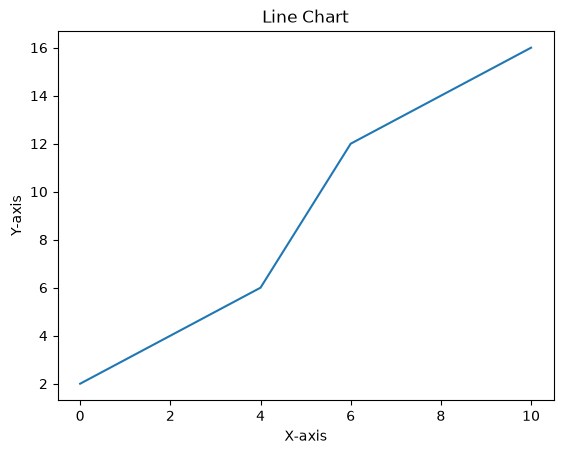

In [9]:
x=[0,2,4,6,8,10]
y=[2,4,6,12,14,16]

plt.plot(x,y)
plt.title('Line Chart')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

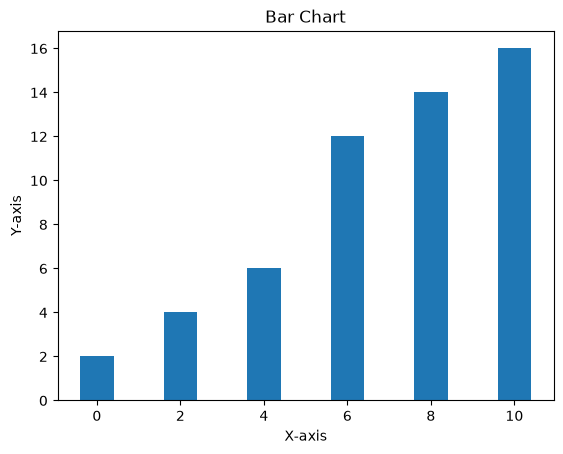

In [10]:
x=[0,2,4,6,8,10]
y=[2,4,6,12,14,16]

plt.bar(x,y)
plt.title('Bar Chart')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

task-1

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'caught'),
  Text(1, 0, 'bowled'),
  Text(2, 0, 'run out'),
  Text(3, 0, 'lbw'),
  Text(4, 0, 'caught and bowled'),
  Text(5, 0, 'stumped'),
  Text(6, 0, 'retired hurt'),
  Text(7, 0, 'hit wicket'),
  Text(8, 0, 'retired out'),
  Text(9, 0, 'obstructing the field')])

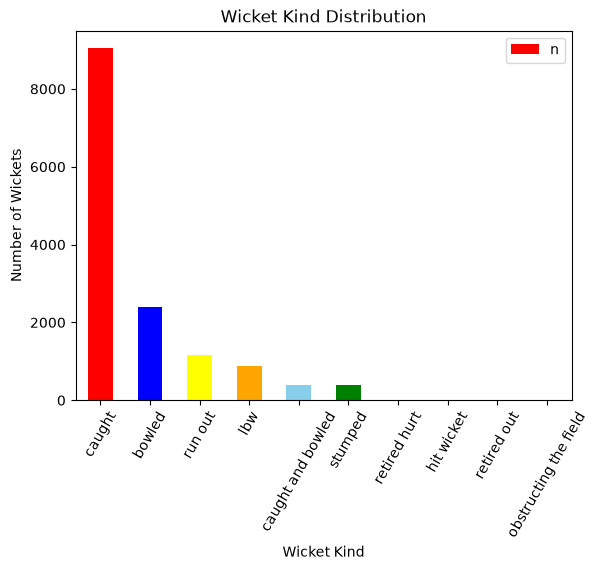

In [27]:
df=pd.read_sql("""SELECT wicket_kind,COUNT(*) AS n
FROM v_ball
WHERE is_wicket=1
GROUP BY wicket_kind
ORDER BY n DESC;
""",con)
df.plot(kind="bar",
        x="wicket_kind",
        y="n",
        title="Wicket Kind Distribution",
        xlabel="Wicket Kind",
        ylabel="Number of Wickets",
          color=["red", "blue", "yellow", "orange","skyblue", "green"])
plt.xticks(rotation=60)

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'AB de Villiers'),
  Text(1, 0, 'CH Gayle'),
  Text(2, 0, 'RG Sharma'),
  Text(3, 0, 'V Kohli'),
  Text(4, 0, 'MS Dhoni')])

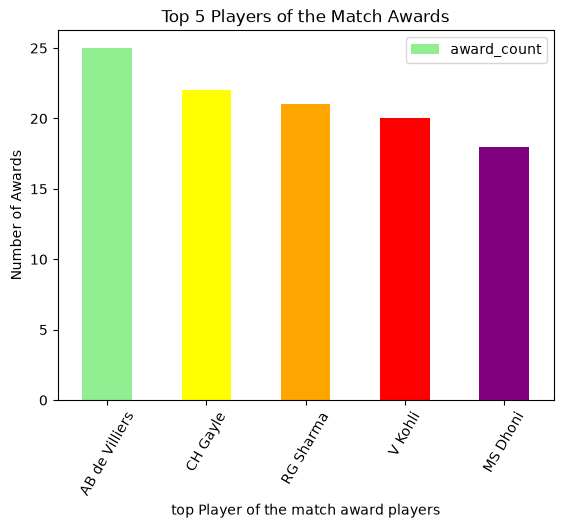

In [41]:
df=pd.read_sql("""
SELECT
    player_of_match AS player,
    COUNT(*) AS award_count
FROM matches_clean
WHERE player_of_match IS NOT NULL
GROUP BY player_of_match
ORDER BY award_count DESC
LIMIT 5;
""",con)
df.plot(kind="bar",
        x="player",
        y="award_count",
        title="Top 5 Players of the Match Awards",
        xlabel="top Player of the match award players",
        ylabel="Number of Awards",
        color=["lightgreen","yellow","orange","red","purple"])
plt.xticks(rotation=60)

<Axes: title={'center': 'Powerplay Strike Rate'}, xlabel='batters', ylabel='Strike Rate'>

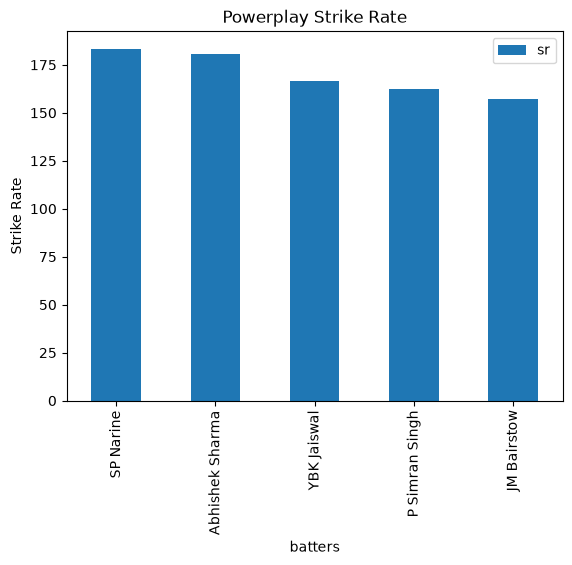

In [40]:
df=pd.read_sql("""
SELECT 
    batter,
    SUM(is_legal) AS balls,
    SUM(batter_runs) AS runs,
    ROUND(
        100.0 * SUM(batter_runs) / SUM(is_legal),
        2
    ) AS sr
FROM v_ball
WHERE phase = 'Powerplay' 
  AND is_wicket = 0
GROUP BY batter
HAVING balls >= 500
ORDER BY sr DESC
LIMIT 5;

""",con)
df.plot(kind="bar",
        x="batter",
        y=["sr"],
        title="Powerplay Strike Rate",
        xlabel="batters",
        ylabel="Strike Rate")


<Axes: title={'center': 'Team-wise Match Wins'}, xlabel='Team', ylabel='Number of Wins'>

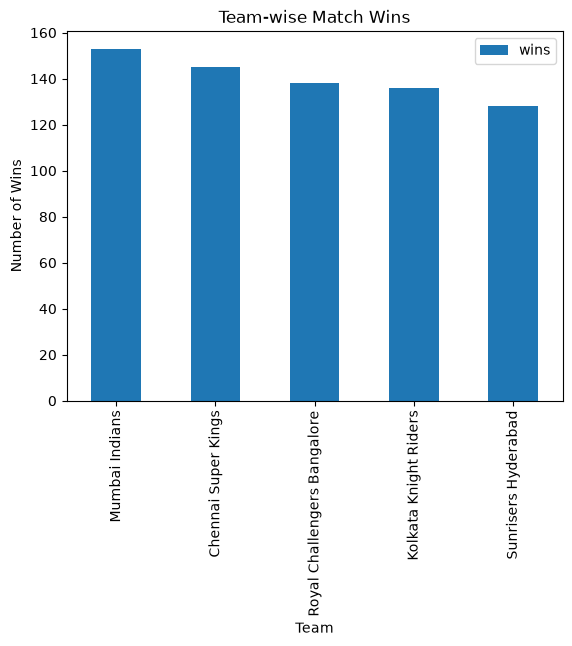

In [48]:
df=pd.read_sql("""
   SELECT match_winner,COUNT(*) AS wins
   FROM matches_clean
   WHERE result='win'
   group by match_winner
   order by wins desc
   LIMIT 5;
  """,con)
df.plot(kind="bar",
       x="match_winner",
       y="wins",
       title="Team-wise Match Wins",
       xlabel="Team",
    ylabel="Number of Wins",)

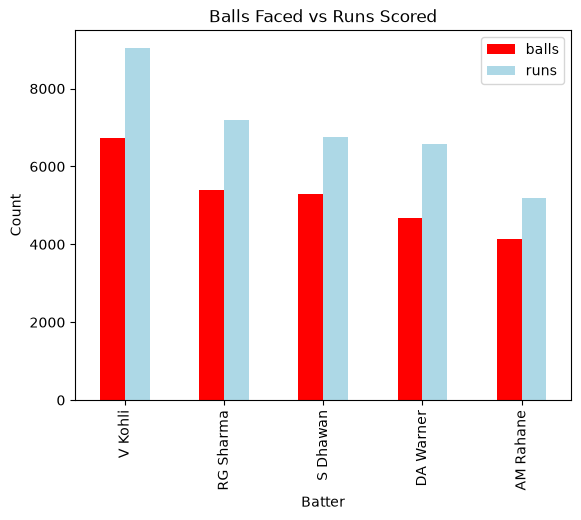

In [50]:
df = q("""SELECT batter, 
       SUM(is_legal) AS balls,
       SUM(batter_runs) AS runs,
       ROUND(100.0 * SUM(batter_runs) / SUM(is_legal), 2) AS strike_rate
FROM v_ball
GROUP BY batter
ORDER BY balls DESC
LIMIT 5;""")

df.plot(kind="bar",
        x="batter",
        y=["balls", "runs"],
        color=["red", "lightblue"],
        title="Balls Faced vs Runs Scored",
        xlabel="Batter",
        ylabel="Count")

plt.show()

<Axes: title={'center': 'Distribution of Pace and Spin Deliveries'}>

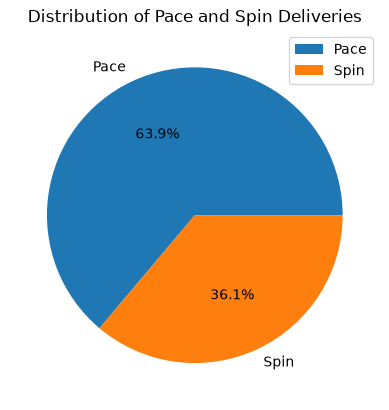

In [51]:
df = pd.read_sql("""SELECT CASE WHEN bowler_type LIKE
       '%Legbreak%' OR bowler_type LIKE
       '%Offbreak%' OR bowler_type LIKE
       '%Orthodox%' OR bowler_type LIKE
       '%Wrist spin%' OR bowler_type LIKE
       '%Googly%' THEN 'Spin' ELSE 'Pace'
       END AS style,
       SUM(is_legal) AS balls
FROM v_ball
WHERE bowler_type IS NOT NULL
AND TRIM(bowler_type) <> ''
GROUP BY style;""", con)

df.plot(kind="pie",
        y="balls",
        labels=df["style"],
        title="Distribution of Pace and Spin Deliveries",
        autopct="%1.1f%%")